In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from posydon.popsyn.synthetic_population import Rates
from posydon.popsyn.rate_calculation import get_shell_comoving_volume
#import cmap

ModuleNotFoundError: No module named 'cmap'

In [63]:
tol_vibrant = cmap.Colormap('tol:vibrant')(np.linspace(0, 1, 7))


In [68]:
for color in tol_vibrant:
    print(color)

[0.         0.46666667 0.73333333 1.        ]
[0.2        0.73333333 0.93333333 1.        ]
[0.         0.6        0.53333333 1.        ]
[0.93333333 0.46666667 0.2        1.        ]
[0.8        0.2        0.06666667 1.        ]
[0.93333333 0.2        0.46666667 1.        ]
[0.73333333 0.73333333 0.73333333 1.        ]


Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


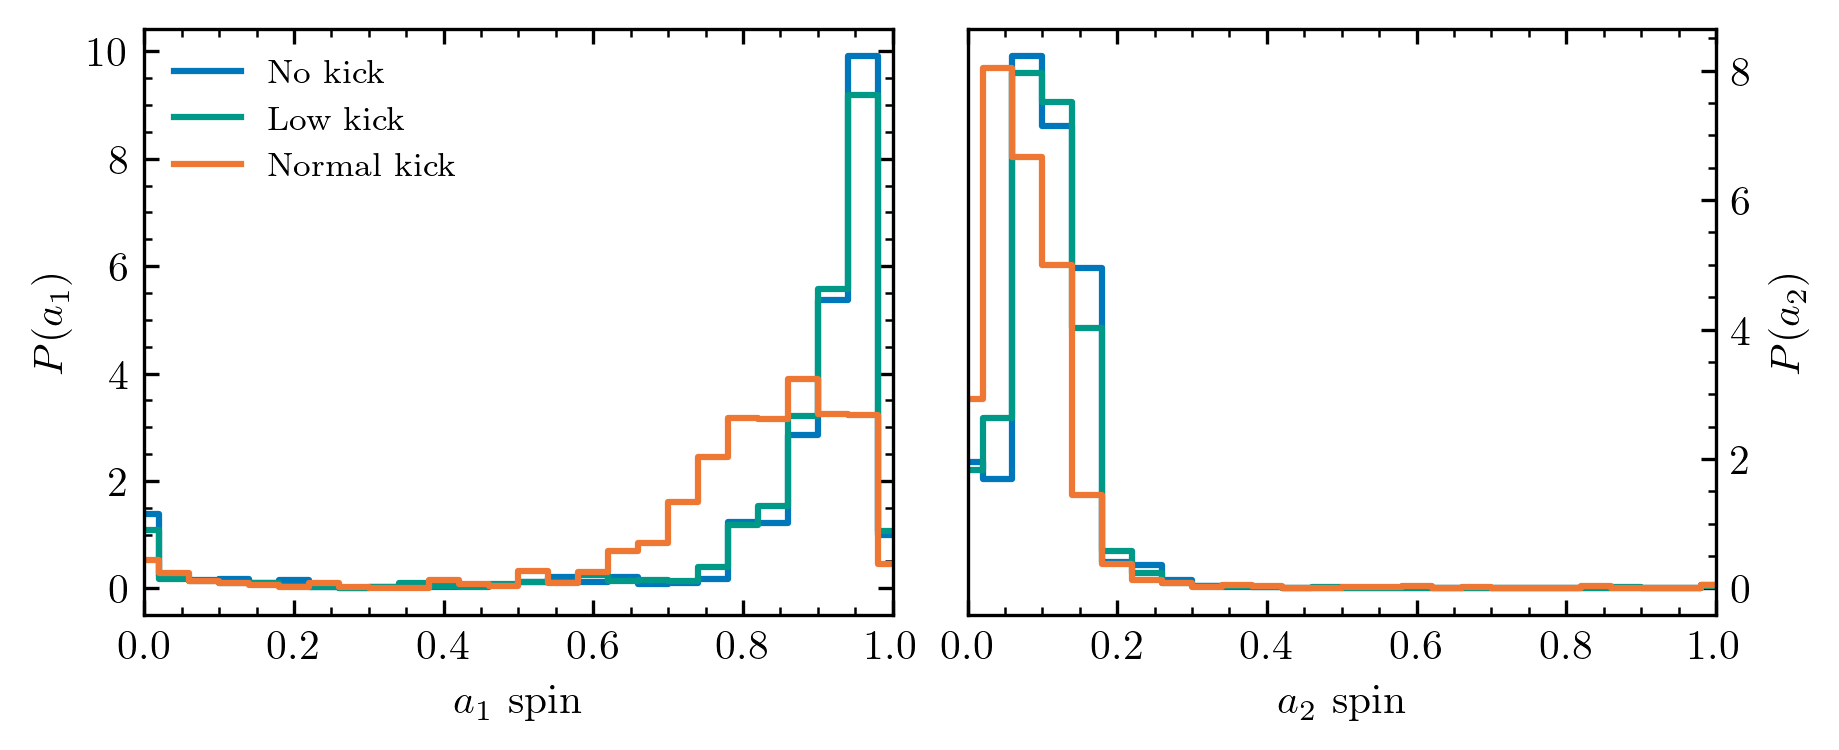

In [177]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)


for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    
    mass_mask = (max_array > 40.0)
    
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_spin_temp = data.population['S1_spin'].copy()
    S1_spin_temp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_temp = data.population['S2_spin'].copy()
    S2_spin_temp[reverse_mask] = data.population['S1_spin'][reverse_mask]

    h, _ = np.histogram(S1_spin_temp[mass_mask], 
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],
                        density=True)

    ax[0].step(spin_bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_spin_temp[mass_mask],
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],
                        density=True)
    ax[1].step(spin_bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$a_1$ spin')
    ax[0].set_ylabel(r'$P(a_1)$')
    ax[1].set_xlabel('$a_2$ spin')


    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(a_2)$')

    ax[0].legend()
    ax[0].set_xlim(0,1)
    ax[1].set_xlim(0,1)


In [82]:
data.population.columns

Index(['time', 'metallicity', 'S1_mass', 'S2_mass', 'S1_spin', 'S2_spin',
       'S1_state', 'S2_state', 'S1_spin_orbit_tilt', 'S2_spin_orbit_tilt',
       'chirp_mass', 'mass_ratio', 'chi_eff', 'channel'],
      dtype='object')

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


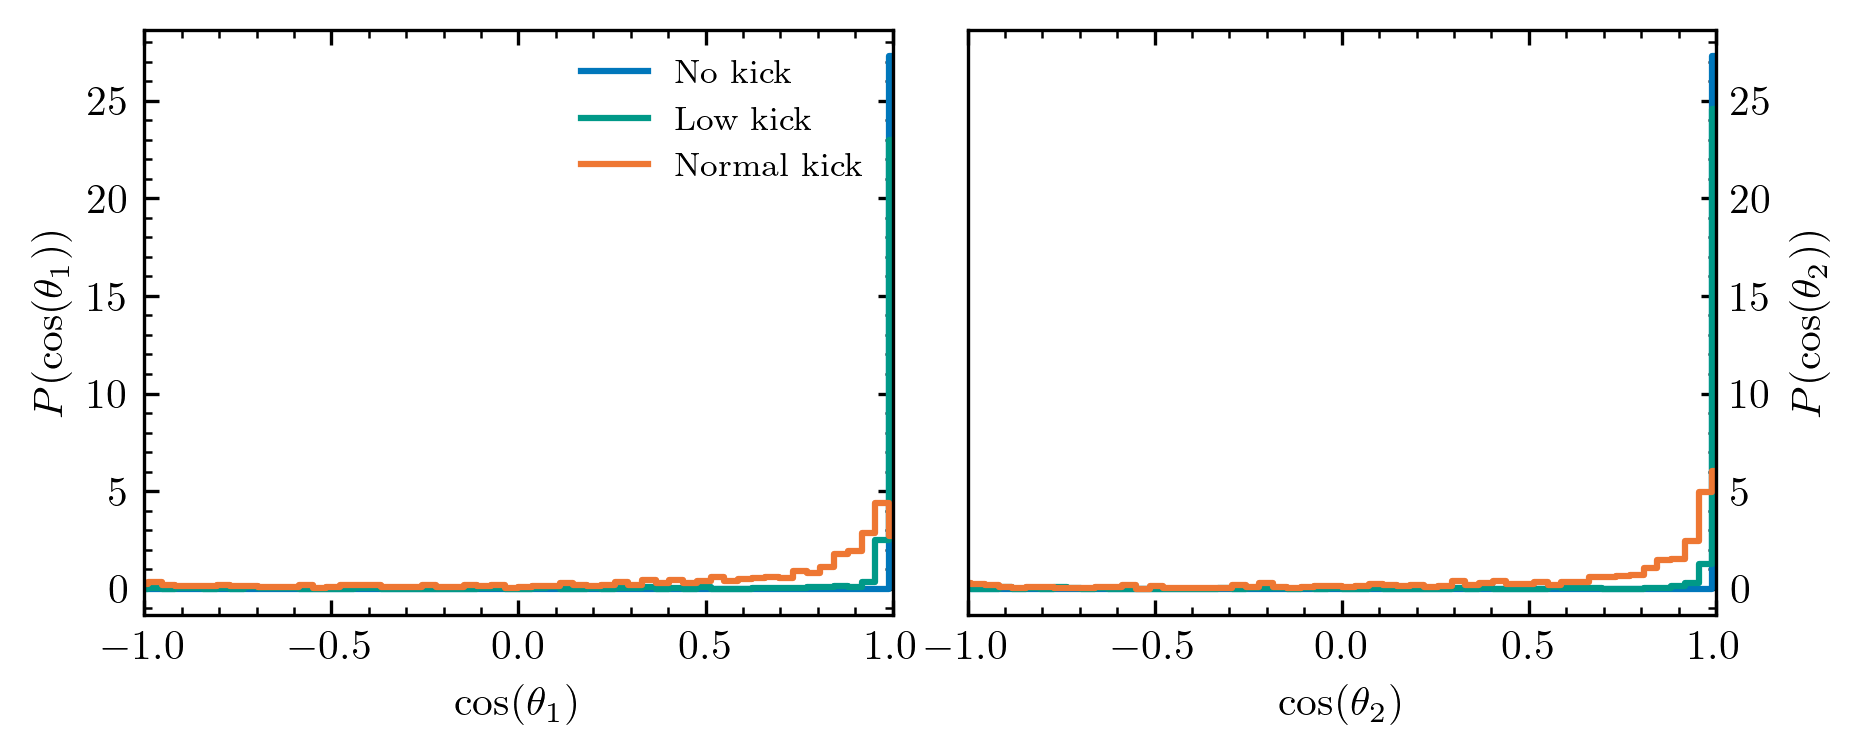

In [108]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)

spin_bins = np.linspace(-1.1, 1.1, 61)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')

    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_array > 40

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_spin_temp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_temp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_temp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_temp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    h, _ = np.histogram(np.cos(S1_spin_temp)[mass_mask], 
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[0].step(spin_bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(np.cos(S2_spin_temp)[mass_mask],
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[1].step(spin_bins[:-1], h, where='post',
                color=color)
    

    ax[0].set_xlabel(r'$\cos(\theta_1)$')
    ax[0].set_ylabel(r'$P(\cos(\theta_1))$')
    ax[1].set_xlabel(r'$\cos(\theta_2)$')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(\cos(\theta_2))$')

    ax[0].legend()
    ax[0].set_xlim(-1,1)
    ax[1].set_xlim(-1,1)

In [192]:
def chi_eff(theta_1, theta_2, a1, a2, m1, m2):
    
    nominator = m1*a1*np.cos(theta_1) + m2*a2*np.cos(theta_2)
    chi_eff = nominator / (m1 + m2)
    return chi_eff

def precession(theta_1, theta_2, a1, a2, m1, m2):
    """Calculate the effective spin precession.
    
    Following the formulation in Gerosa+2021, which 
    is used in LIGO/Virgo analyses.
    
    Parameters
    ----------
    theta_1 : float or np.ndarray
        Tilt angle of the primary spin (in radians).
    theta_2 : float or np.ndarray
        Tilt angle of the secondary spin (in radians).
    a1 : float or np.ndarray
        Dimensionless spin magnitude of the primary.
    a2 : float or np.ndarray
        Dimensionless spin magnitude of the secondary.
    m1 : float or np.ndarray
        Mass of the primary.
    m2 : float or np.ndarray
        Mass of the secondary.
    """
    q = m2/m1
    a_1_perp = np.abs(a1 * np.sin(theta_1))
    a_2_perp = q * ((4*q + 3)/(4+3*q)) * a2 * np.sin(theta_2)
    chi_p = np.maximum(a_1_perp, a_2_perp)
    return chi_p

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


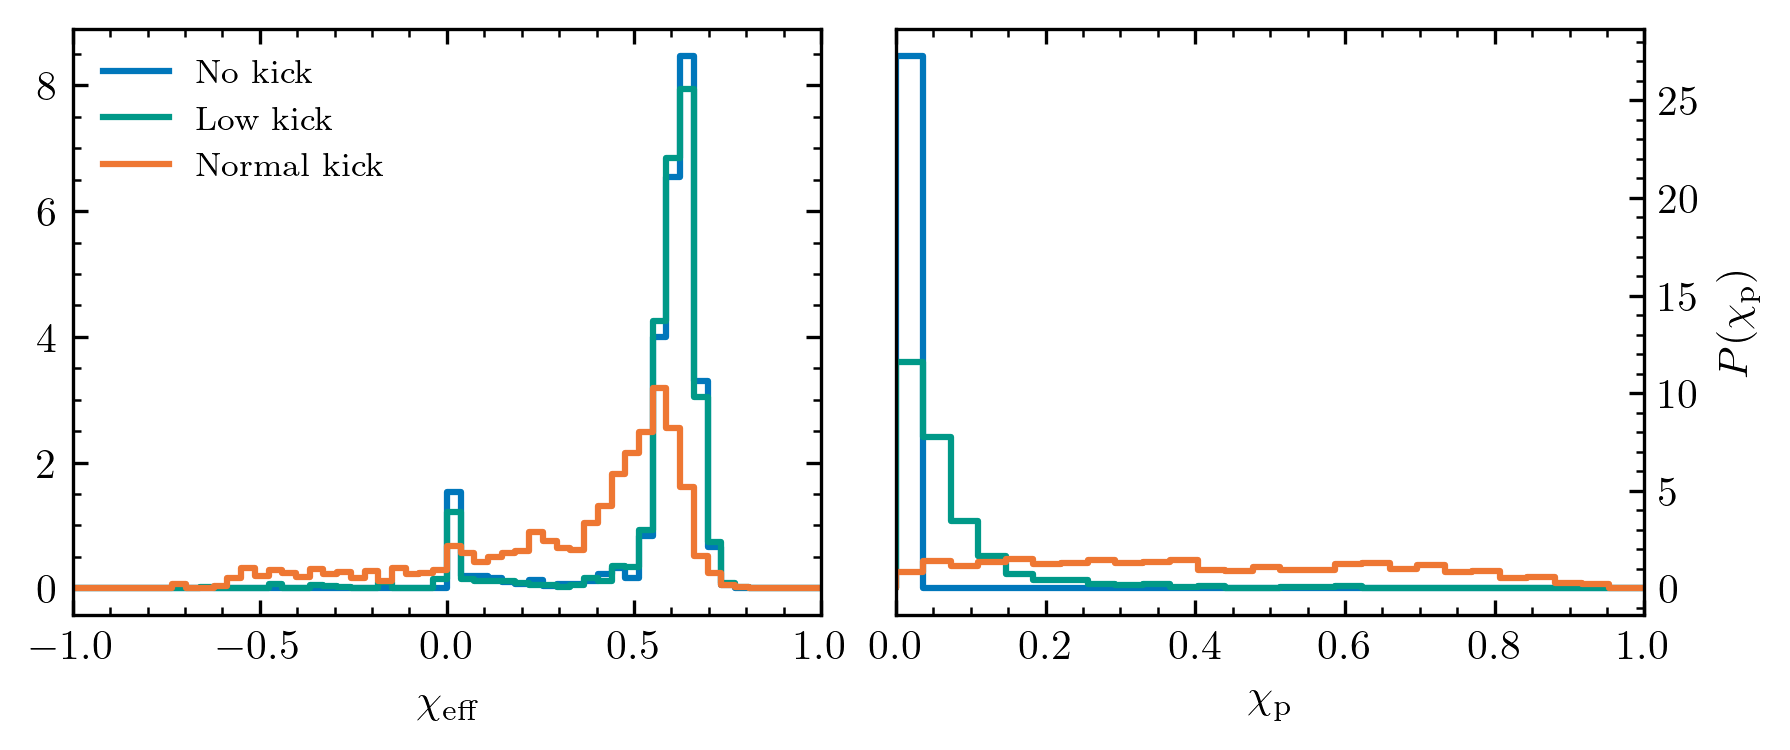

In [174]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)

bins = np.linspace(-1.1, 1.1, 61)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')

    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_array > 40


    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']

    S1_max = data.population['S1_mass'].copy()
    S1_max[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_min = data.population['S2_mass'].copy()
    S2_min[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tilt_max = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_max[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_min = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_min[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]
    S1_spin_max = data.population['S1_spin'].copy()
    S1_spin_max[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_min = data.population['S2_spin'].copy()
    S2_spin_min[reverse_mask] = data.population['S1_spin'][reverse_mask]
    
    
    
    chi_eff_array  = chi_eff(S1_spin_tilt_max,
                        S2_spin_tilt_min,
                        S1_spin_max,
                        S2_spin_min,
                        S1_max,
                        S2_min)

    h, _ = np.histogram(chi_eff_array[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)
    
    chi_p = precession(S1_spin_tilt_max, 
                       S2_spin_tilt_min,
                       S1_spin_max,
                       S2_spin_min,
                       S1_max,
                       S2_min)

    h, _ = np.histogram(chi_p[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[1].step(bins[:-1], h, where='post',
                color=color)
    

    ax[0].set_xlabel(r'$\chi_\mathrm{eff}$')
    #ax[0].set_ylabel(r'$P(\cos(\theta_1))$')
    ax[1].set_xlabel(r'$\chi_\mathrm{p}$')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(\chi_\mathrm{p})$')

    ax[0].legend()
    ax[0].set_xlim(-1,1)
    ax[1].set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


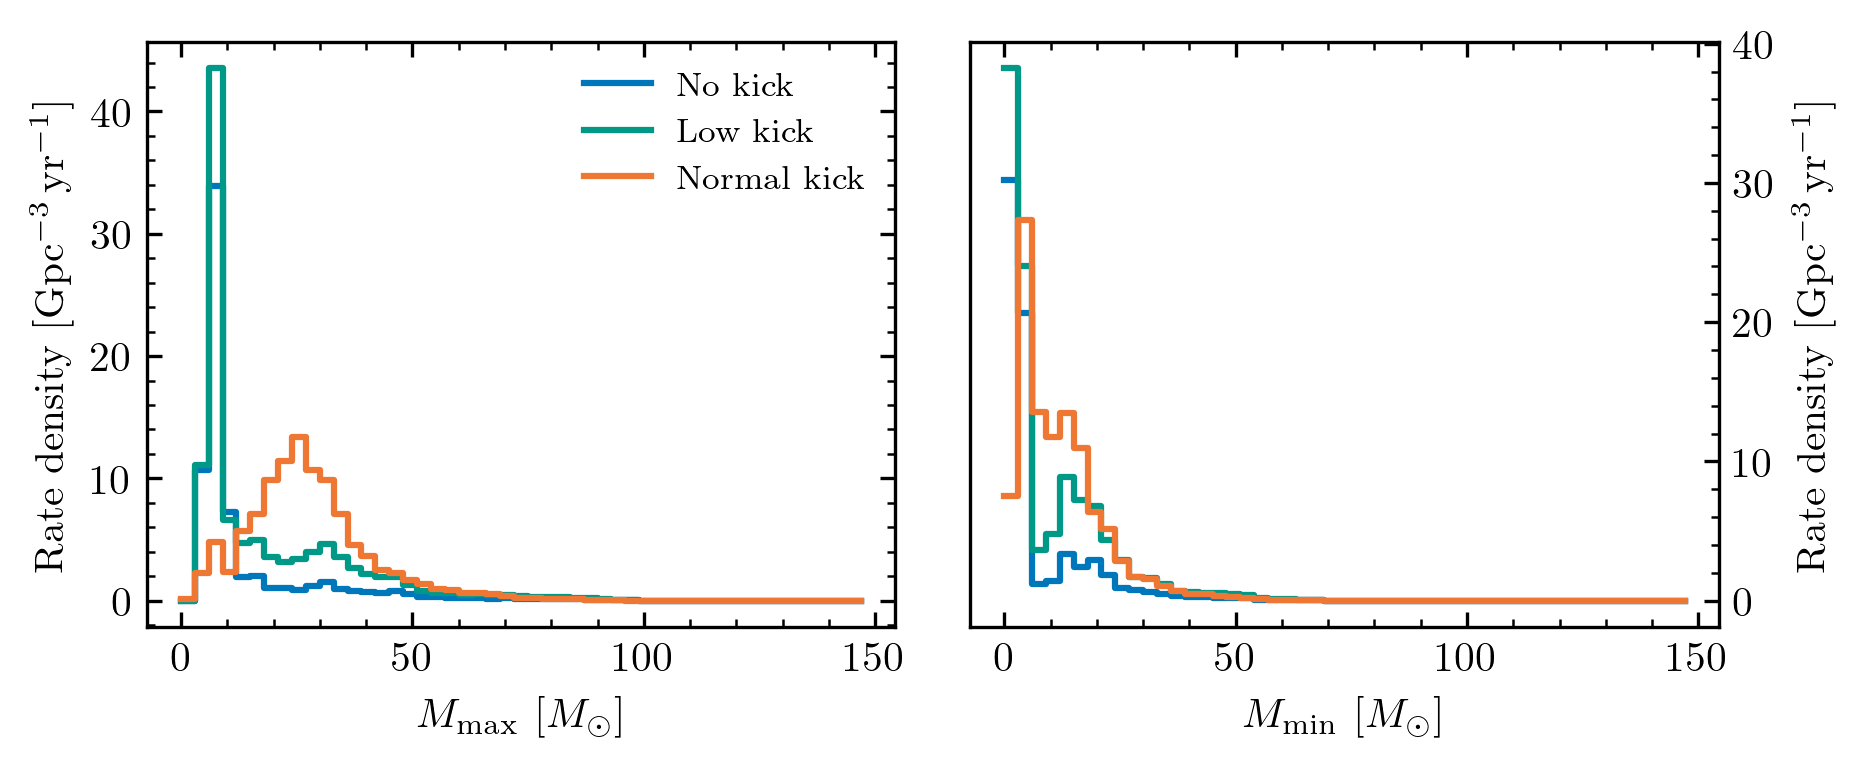

In [ ]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,150,51)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]

    h, _ = np.histogram(S1_mass_tmp, 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /= (np.diff(bins)*volume)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_mass_tmp,
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /=( np.diff(bins)*volume)

    ax[1].step(bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$M_\mathrm{max}$ [$M_\odot$]')
    ax[0].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')
    ax[1].set_xlabel('$M_\mathrm{min}$ [$M_\odot$]')


    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')

    ax[0].legend()
    #ax[0].set_xlim(0,1)
    #ax[1].set_xlim(0,1)
    #ax[0].set_ylim(0,2500)
    #ax[1].set_ylim(0,2500)


Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


(0.0, 5.332990661136814)

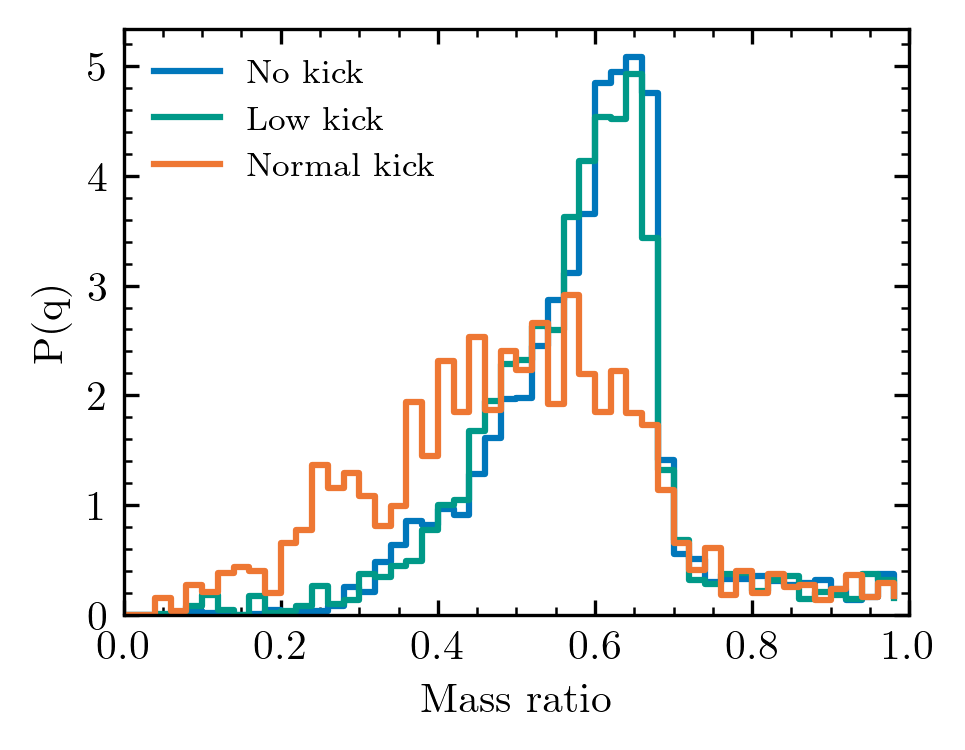

In [182]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,1,51)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume

    mass_ratio = data.population['mass_ratio']
    
    h, _ = np.histogram(mass_ratio[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel(r'P(q)')

    ax.legend()

    ax.set_xlim(0,1)
    
ax.set_ylim(0)

# GRMHD

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


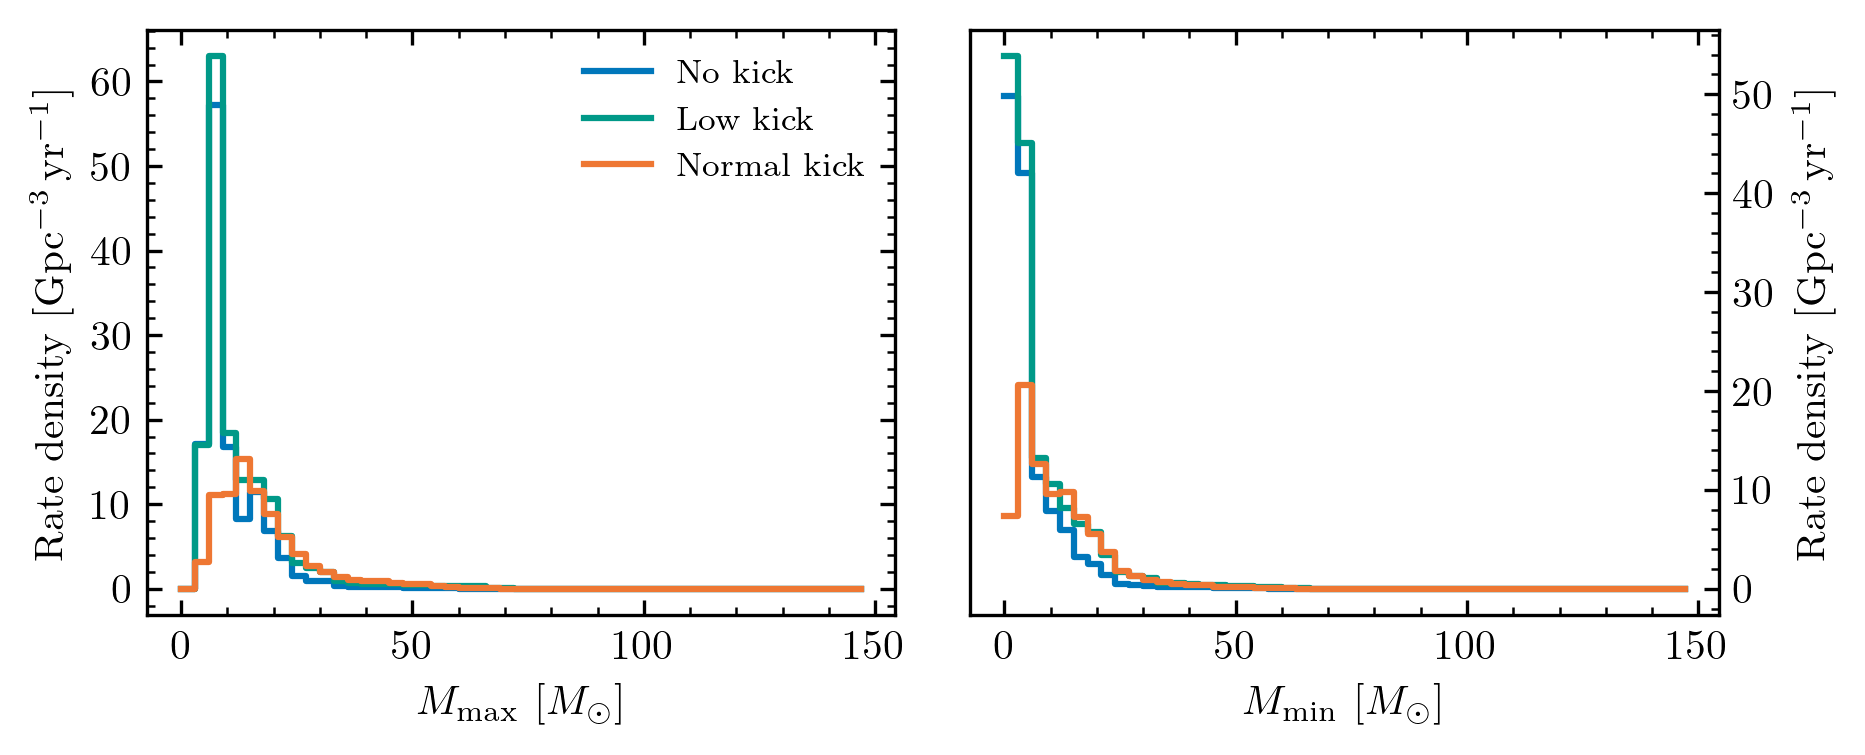

In [81]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250708_SMT_focus/IF/run_20",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_05",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_03"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,150,51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]

    h, _ = np.histogram(S1_mass_tmp, 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /= (np.diff(bins)*volume)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_mass_tmp,
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /=( np.diff(bins)*volume)

    ax[1].step(bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$M_\mathrm{max}$ [$M_\odot$]')
    ax[0].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')
    ax[1].set_xlabel('$M_\mathrm{min}$ [$M_\odot$]')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')

    ax[0].legend()
    #ax[0].set_xlim(0,1)
    #ax[1].set_xlim(0,1)
    #ax[0].set_ylim(0,2500)
    #ax[1].set_ylim(0,2500)


# GRMHD

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


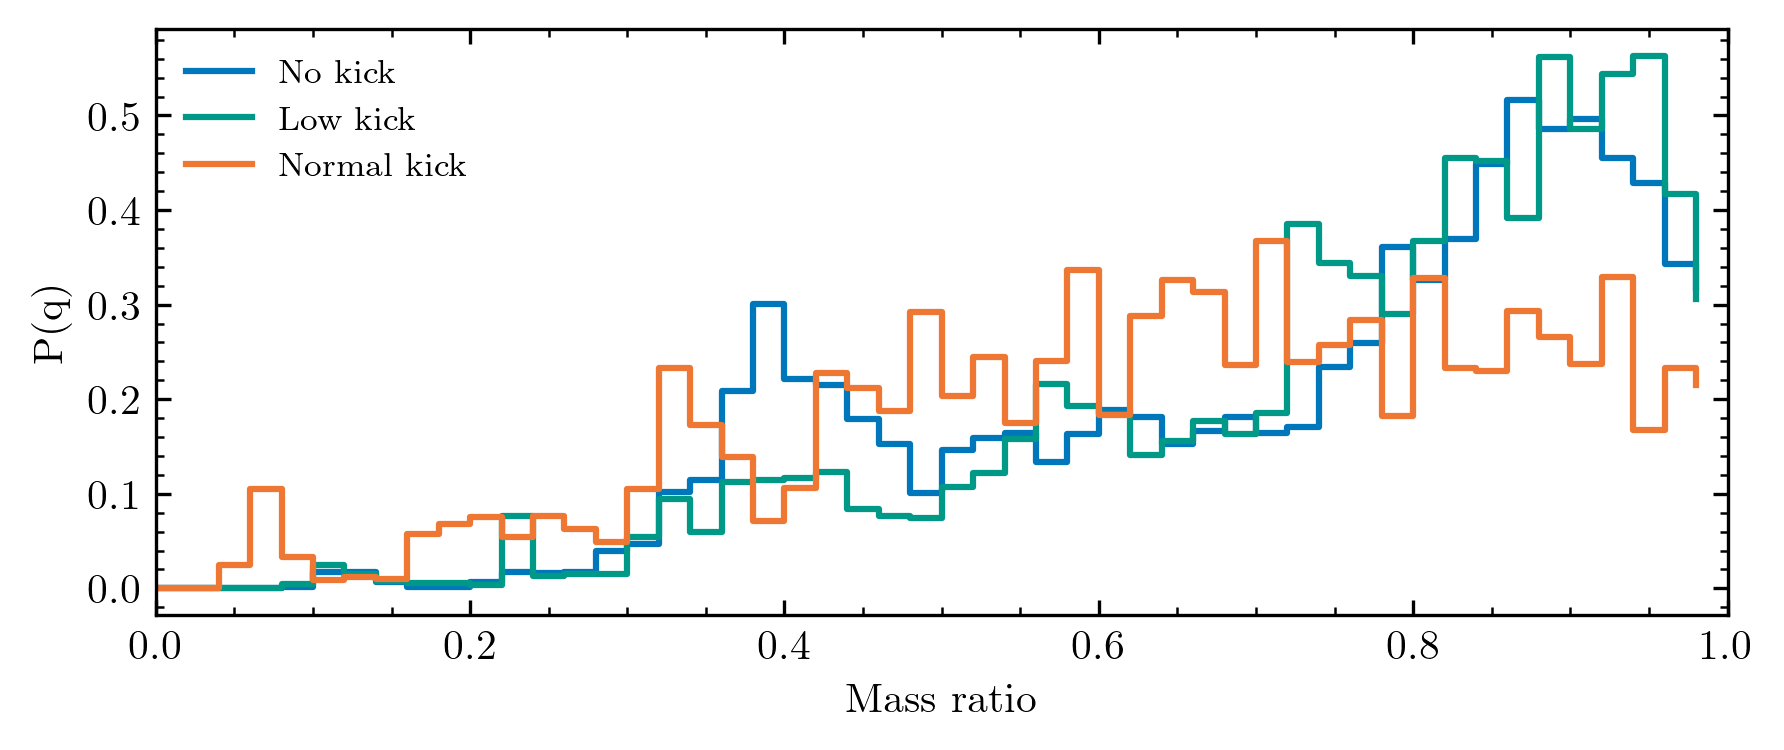

In [194]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume

    mass_ratio = data.population['mass_ratio']
    
    h, _ = np.histogram(mass_ratio[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


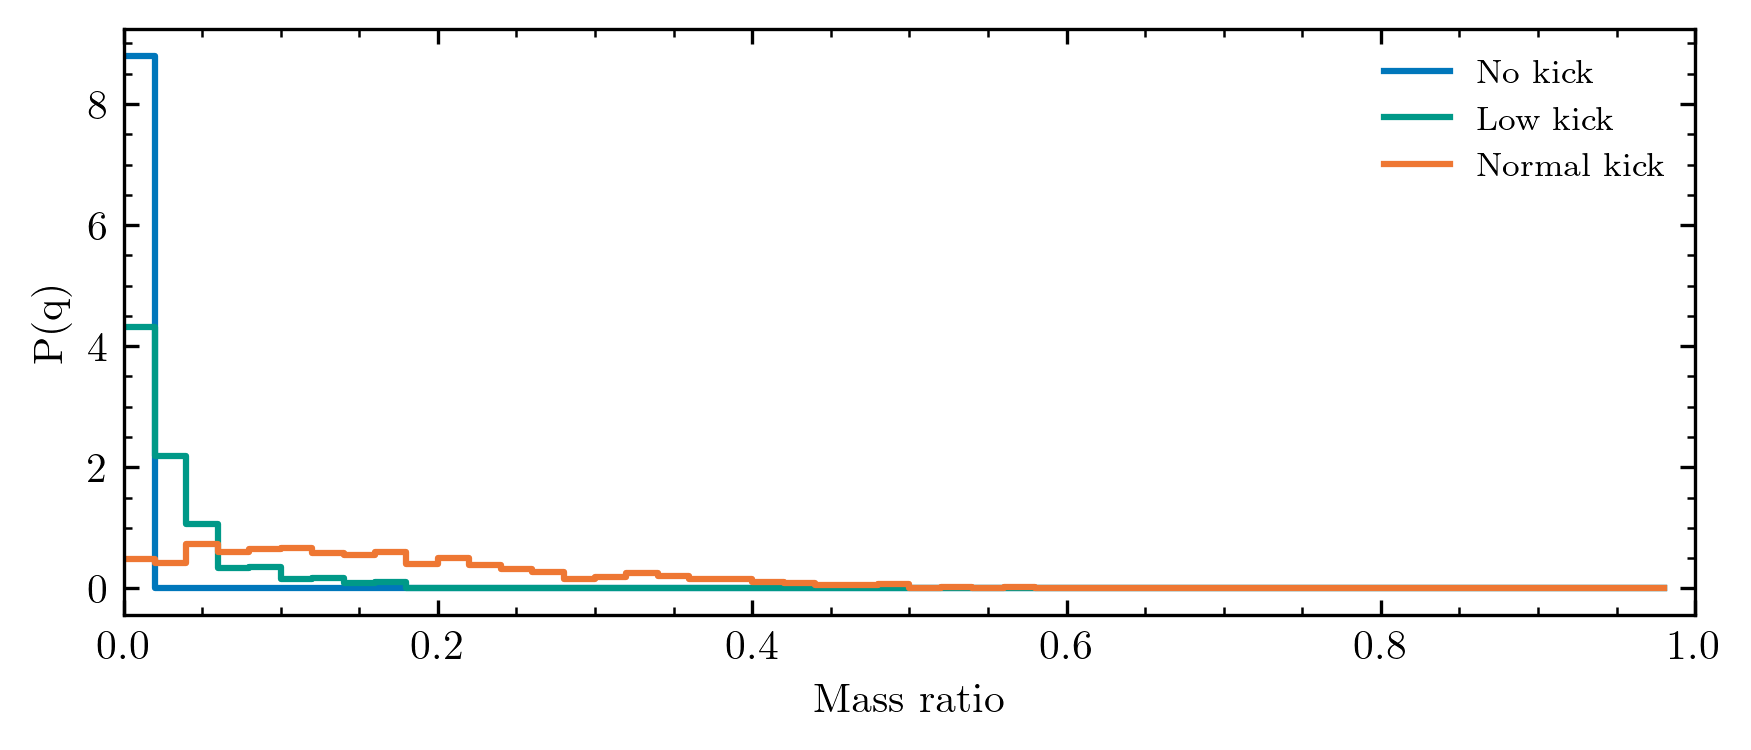

In [195]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = precession(S1_spin_tilt_tmp,
                            S2_spin_tilt_tmp,
                            S1_spin_tmp,
                            S2_spin_tmp,
                            S1_mass_tmp,
                            S2_mass_tmp)

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


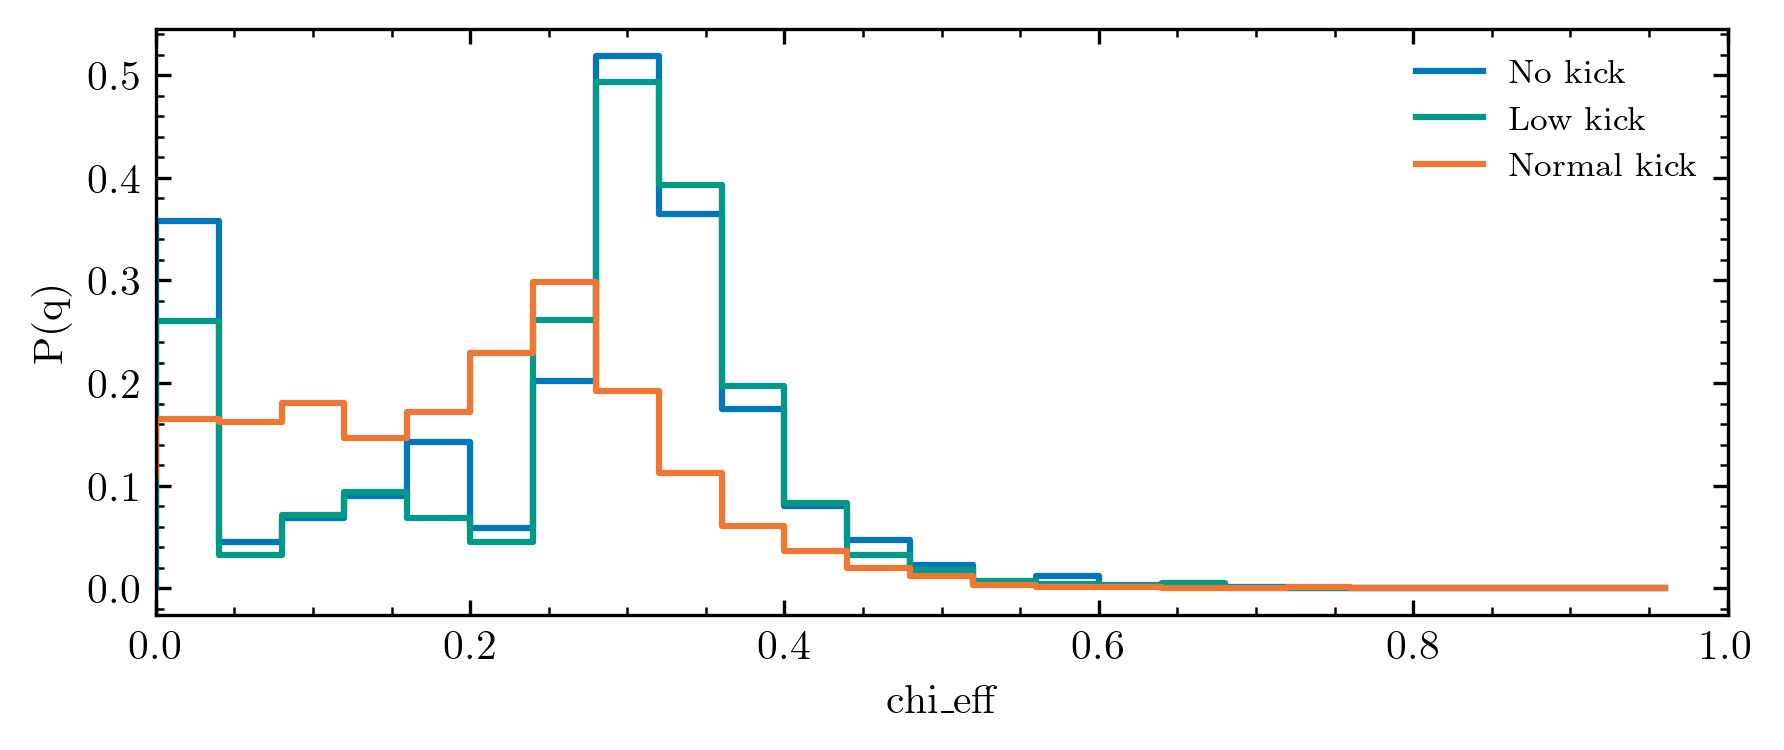

In [196]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(-1, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = chi_eff(S1_spin_tilt_tmp,
                            S2_spin_tilt_tmp,
                            S1_spin_tmp,
                            S2_spin_tmp,
                            S1_mass_tmp,
                            S2_mass_tmp)

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('chi_eff')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


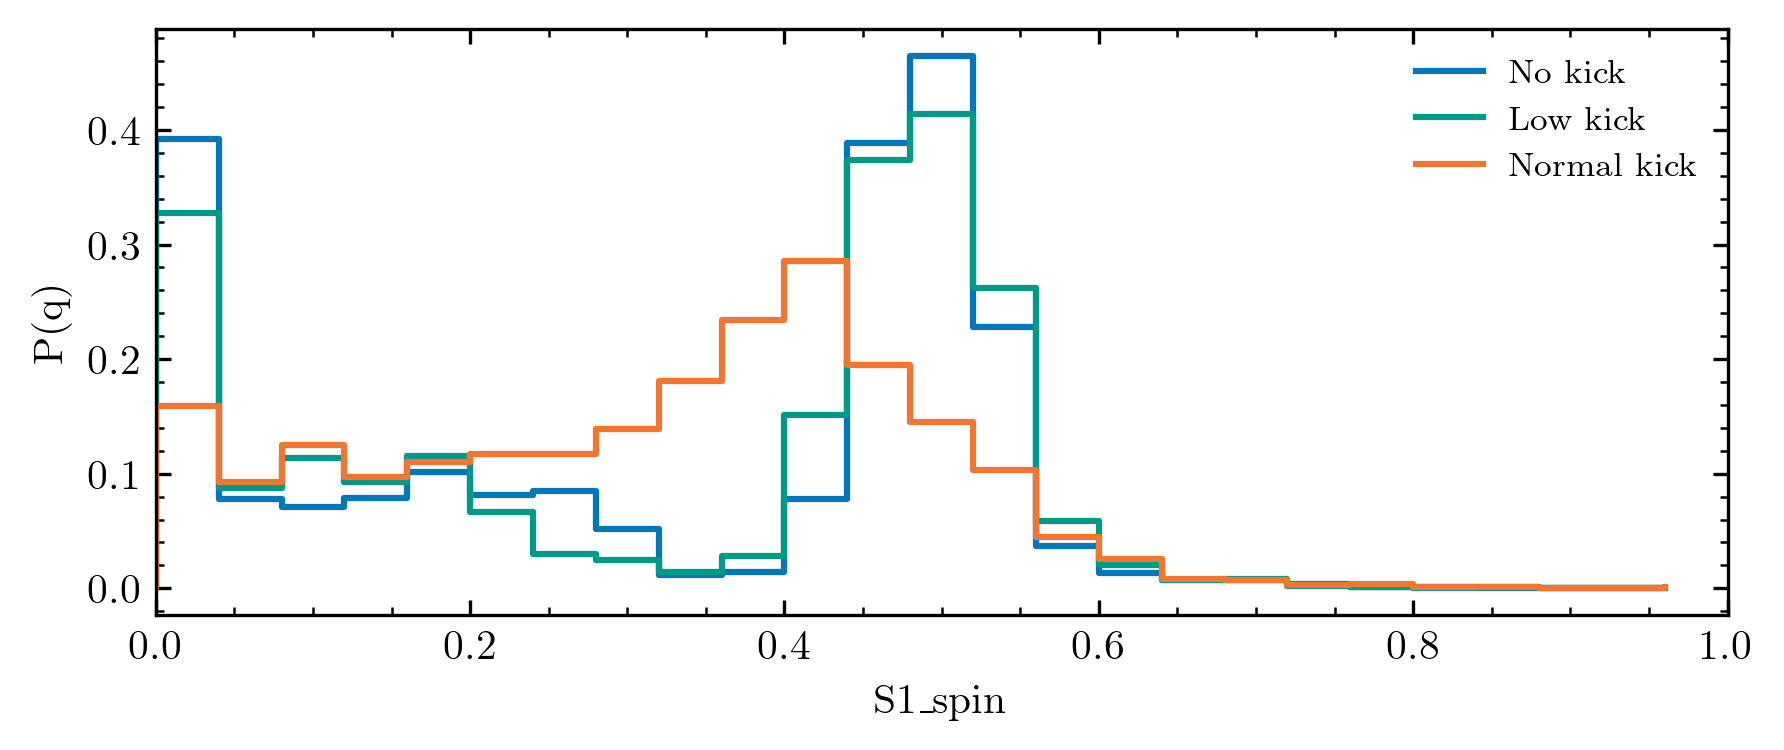

In [198]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(-1, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = S1_spin_tmp

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('S1_spin')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)
    